# Exploratory Data Analysis

This notebook performs an exploratory data analysis (EDA) on the DataCo supply chain dataset spanning January 2015 to January 2018.

### Main goals
- understand the dataset structure, data types, and temporal coverage
- inspect variable distributions and identify potential outliers
- analyze trends in order volume and sales by month
- review categorical variables and their value distributions  
- optimize data types to reduce memory usage and improve performance
- prepare clean and processed data for feature engineering and predictive modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import EngFormatter
from pathlib import Path
from config.settings import EXPORT_DIR

In [2]:
export_dir = Path(EXPORT_DIR)

In [3]:
# Load DataCo supply chain dataset
url = "https://raw.githubusercontent.com/ashishpatel26/DataCo-SMART-SUPPLY-CHAIN-FOR-BIG-DATA-ANALYSIS/main/DataCoSupplyChainDataset.csv"
df = pd.read_csv(url, encoding='latin-1', parse_dates=['order date (DateOrders)'])
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
# Check dataset time coverage
print('Dataset from: ', df['order date (DateOrders)'].min())
print('Dataset to: ', df['order date (DateOrders)'].max())

Dataset from:  2015-01-01 00:00:00
Dataset to:  2018-01-31 23:38:00


---
## Reconstruction of varaibles

In [5]:
df['Order Status'].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [6]:
# Unifing 'Order Status'
status_map = {
    'CLOSED': 'COMPLETE',
    'ON_HOLD': 'PAYMENT_REVIEW',
    'SUSPECTED_FRAUD': 'PAYMENT_REVIEW',
}

df['Order Status'] = df['Order Status'].replace(status_map)

In [7]:
df['Order Status'].value_counts()

Order Status
COMPLETE           79107
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
PAYMENT_REVIEW     15759
CANCELED            3692
Name: count, dtype: int64

In [8]:
# Correct calculation of 'Order Item Total'
df['Order Item Total'] = df['Order Item Quantity']*(df['Order Item Product Price'] - df['Order Item Discount'])

---

In [9]:
# Helper plotting function keep the EDA workflow readable and reduce duplicated plotting code

def plot_orders_and_sales(df):
    monthly_orders = df.groupby(df['order date (DateOrders)'].dt.to_period('M')).size()
    monthly_orders.index = monthly_orders.index.astype(str)
    
    monthly_total = df.groupby(df['order date (DateOrders)'].dt.to_period('M'))['Order Item Total'].sum()
    monthly_total.index = monthly_total.index.astype(str)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    color = 'black'
    monthly_orders.plot(color=color, marker='o', ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('Number of orders', color=color)
    ax.yaxis.set_major_formatter(EngFormatter())
    ax.tick_params(axis='y', labelcolor=color)
    
    ax1 = ax.twinx()
    color = 'green'
    monthly_total.plot(color=color, marker='s', ax=ax1)
    ax1.set_ylabel('Total sales (€)', color=color)
    ax1.yaxis.set_major_formatter(EngFormatter())
    ax1.tick_params(axis='y', labelcolor=color)
    
    plt.title('Number of Orders vs. Total Sales')
    plt.tight_layout()
    plt.show()

In [10]:
# Keep only relevant columns
keep_columns = [
    'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Department Name', 'Market', 'order date (DateOrders)',
    'Order Item Discount', 'Order Item Product Price',
    'Order Item Quantity', 'Order Item Total', 'Order Status', 
    'Product Category Id', 'Shipping Mode'
]

df = df[keep_columns].copy()
df.head()

,Days for shipping (real),Days for shipment (scheduled),Department Name,Market,order date (DateOrders),Order Item Discount,Order Item Product Price,Order Item Quantity,Order Item Total,Order Status,Product Category Id,Shipping Mode
0,3,4,Fitness,Pacific Asia,2018-01-31 22:56:00,13.110000,327.75,1,314.640000,COMPLETE,73,Standard Class
1,5,4,Fitness,Pacific Asia,2018-01-13 12:27:00,16.389999,327.75,1,311.360001,PENDING,73,Standard Class
2,4,4,Fitness,Pacific Asia,2018-01-13 12:06:00,18.030001,327.75,1,309.719999,COMPLETE,73,Standard Class
3,3,4,Fitness,Pacific Asia,2018-01-13 11:45:00,22.940001,327.75,1,304.809999,COMPLETE,73,Standard Class
4,2,4,Fitness,Pacific Asia,2018-01-13 11:24:00,29.500000,327.75,1,298.250000,PENDING_PAYMENT,73,Standard Class


---

In [11]:
# Review summary statistics to spot extreme values and inconsistent scales
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Days for shipping (real),180519.0,3.497654,0.0,2.0,3.0,5.0,6.0,1.623722
Days for shipment (scheduled),180519.0,2.931847,0.0,2.0,4.0,4.0,4.0,1.374449
order date (DateOrders),180519,2016-06-12 17:47:04.669868544,2015-01-01 00:00:00,2015-09-21 13:49:00,2016-06-11 13:06:00,2017-03-01 08:42:00,2018-01-31 23:38:00,NaN
Order Item Discount,180519.0,20.664741,0.0,5.4,14.0,29.99,500.0,21.800901
Order Item Product Price,180519.0,141.23255,9.99,50.0,59.990002,199.990005,1999.98999,139.732492
Order Item Quantity,180519.0,2.127638,1.0,1.0,1.0,3.0,5.0,1.453451
Order Item Total,180519.0,157.733383,-125.0,75.0,124.790006,209.890003,1939.98999,122.850134
Product Category Id,180519.0,31.851451,2.0,18.0,29.0,45.0,76.0,15.640064


In [12]:
# Inspect categorical variables
df.describe(exclude="number").T

,count,unique,top,freq,mean,min,25%,50%,75%,max
Department Name,180519,11,Fan Shop,66861,NaN,NaN,NaN,NaN,NaN,NaN
Market,180519,5,LATAM,51594,NaN,NaN,NaN,NaN,NaN,NaN
order date (DateOrders),180519,NaN,NaN,NaN,2016-06-12 17:47:04.669868544,2015-01-01 00:00:00,2015-09-21 13:49:00,2016-06-11 13:06:00,2017-03-01 08:42:00,2018-01-31 23:38:00
Order Status,180519,6,COMPLETE,79107,NaN,NaN,NaN,NaN,NaN,NaN
Shipping Mode,180519,4,Standard Class,107752,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Check dataset structure and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Days for shipping (real)       180519 non-null  int64         
 1   Days for shipment (scheduled)  180519 non-null  int64         
 2   Department Name                180519 non-null  object        
 3   Market                         180519 non-null  object        
 4   order date (DateOrders)        180519 non-null  datetime64[ns]
 5   Order Item Discount            180519 non-null  float64       
 6   Order Item Product Price       180519 non-null  float64       
 7   Order Item Quantity            180519 non-null  int64         
 8   Order Item Total               180519 non-null  float64       
 9   Order Status                   180519 non-null  object        
 10  Product Category Id            180519 non-null  int64         
 11  

---
## Variable analysis

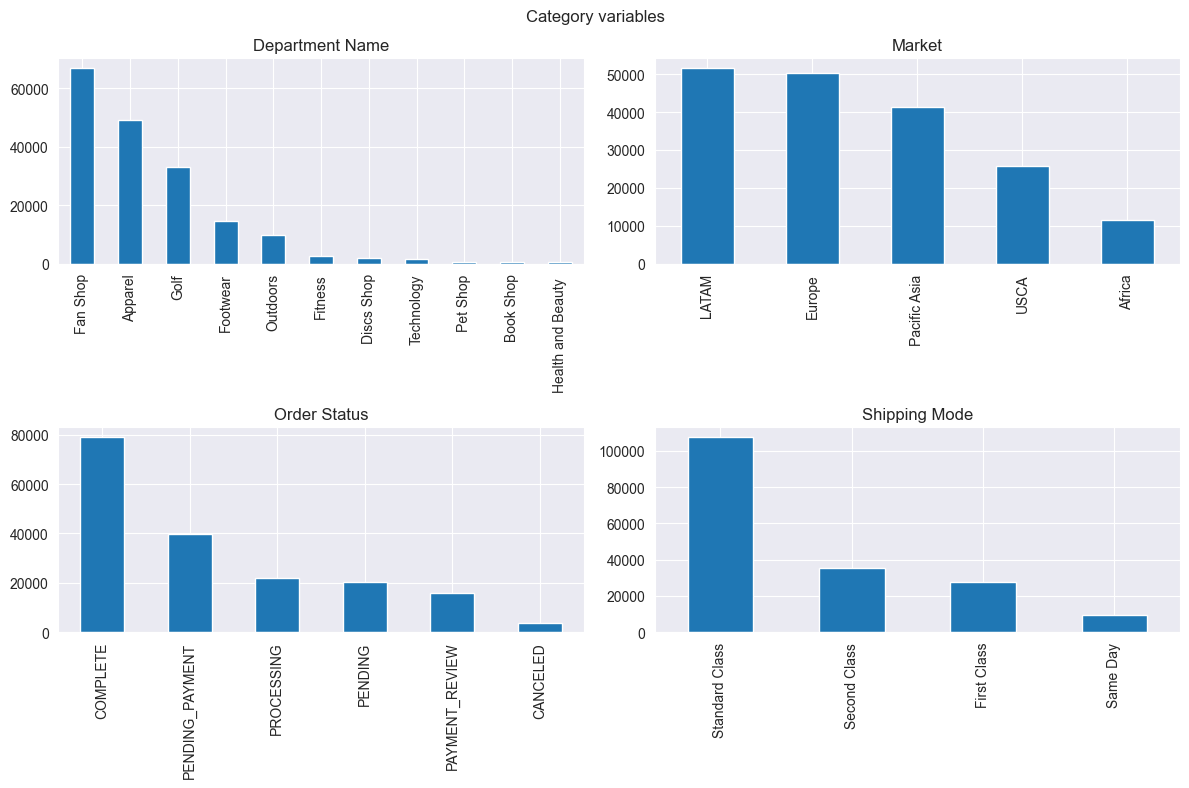

In [14]:
category_columns = [
    'Department Name', 'Market', 'Order Status', 'Shipping Mode'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(category_columns):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
        
plt.suptitle('Category variables')
plt.tight_layout()

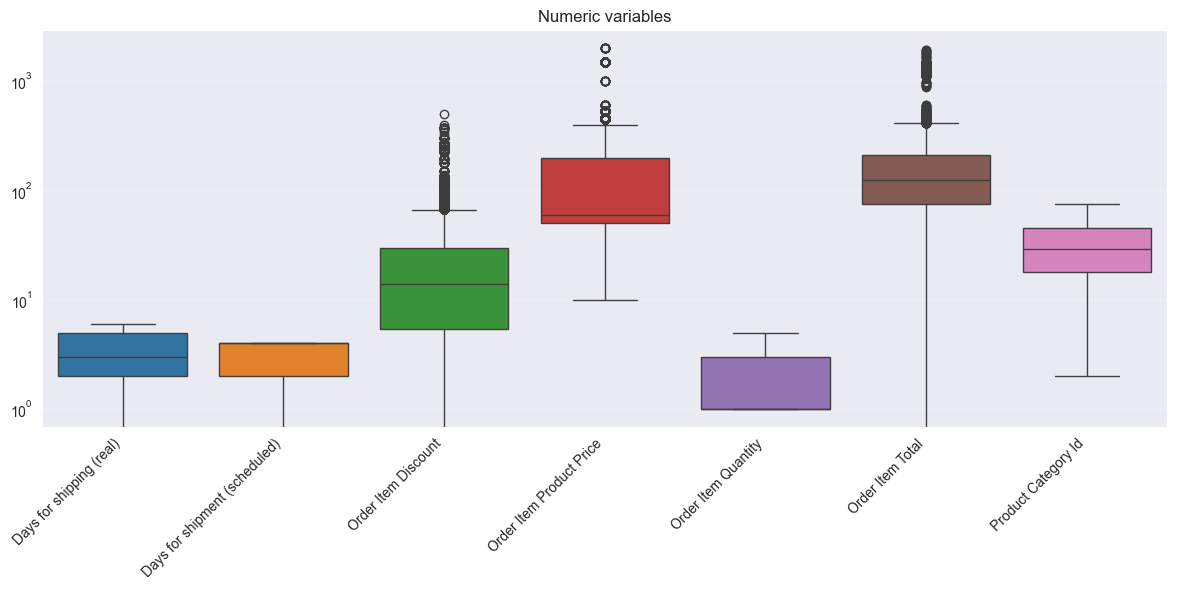

In [15]:
numeric_df = df.select_dtypes(include=['number'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=numeric_df, ax=ax)
ax.set_yscale('log')
ax.set_title('Numeric variables')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

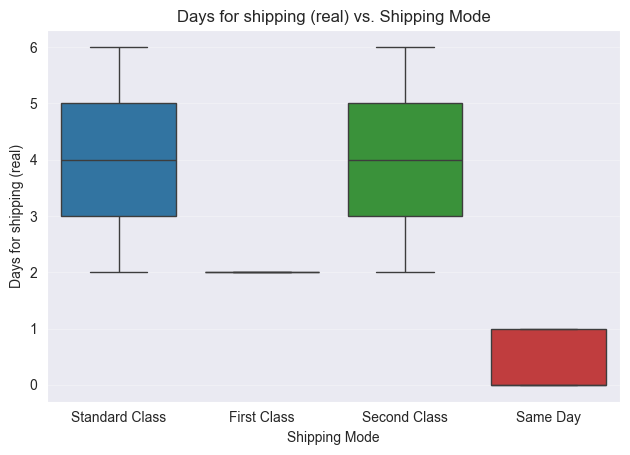

In [16]:
sns.boxplot(df, y='Days for shipping (real)', x='Shipping Mode', hue='Shipping Mode')
plt.title('Days for shipping (real) vs. Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Days for shipping (real)')
plt.suptitle('')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

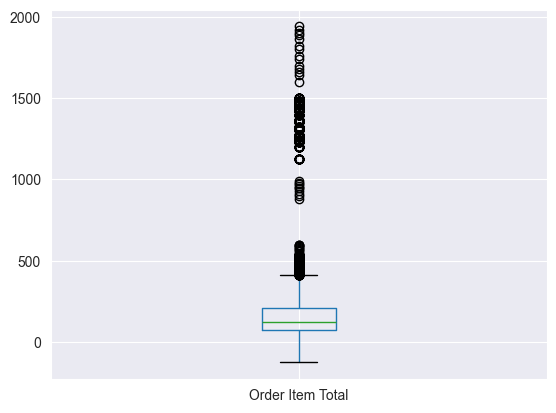

In [17]:
df.boxplot('Order Item Total');

In [18]:
# Reconstructrion of 'Order Item Total' to solve negative sales
min_price = df['Order Item Product Price'].min().round(2)

low_total_mask  = (df['Order Item Total'] <= 20)
df.loc[low_total_mask, 'Order Item Discount'] = df.loc[low_total_mask , 'Order Item Product Price'] - min_price

df['Order Item Total'] = df['Order Item Quantity']*(df['Order Item Product Price'] - df['Order Item Discount'])
df.head()

,Days for shipping (real),Days for shipment (scheduled),Department Name,Market,order date (DateOrders),Order Item Discount,Order Item Product Price,Order Item Quantity,Order Item Total,Order Status,Product Category Id,Shipping Mode
0,3,4,Fitness,Pacific Asia,2018-01-31 22:56:00,13.110000,327.75,1,314.640000,COMPLETE,73,Standard Class
1,5,4,Fitness,Pacific Asia,2018-01-13 12:27:00,16.389999,327.75,1,311.360001,PENDING,73,Standard Class
2,4,4,Fitness,Pacific Asia,2018-01-13 12:06:00,18.030001,327.75,1,309.719999,COMPLETE,73,Standard Class
3,3,4,Fitness,Pacific Asia,2018-01-13 11:45:00,22.940001,327.75,1,304.809999,COMPLETE,73,Standard Class
4,2,4,Fitness,Pacific Asia,2018-01-13 11:24:00,29.500000,327.75,1,298.250000,PENDING_PAYMENT,73,Standard Class


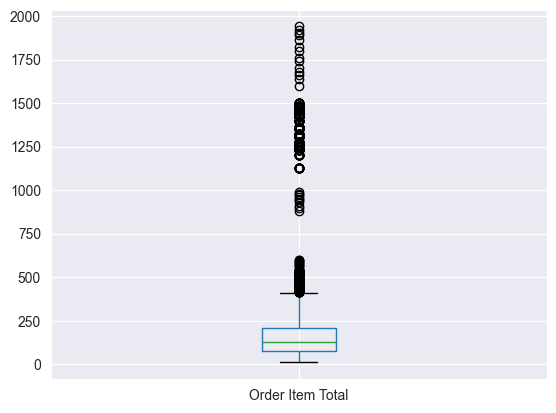

In [19]:
# Verification
df.boxplot('Order Item Total');

---
## Trends

Aggregating orders and sales by month reveals medium-term business patterns.

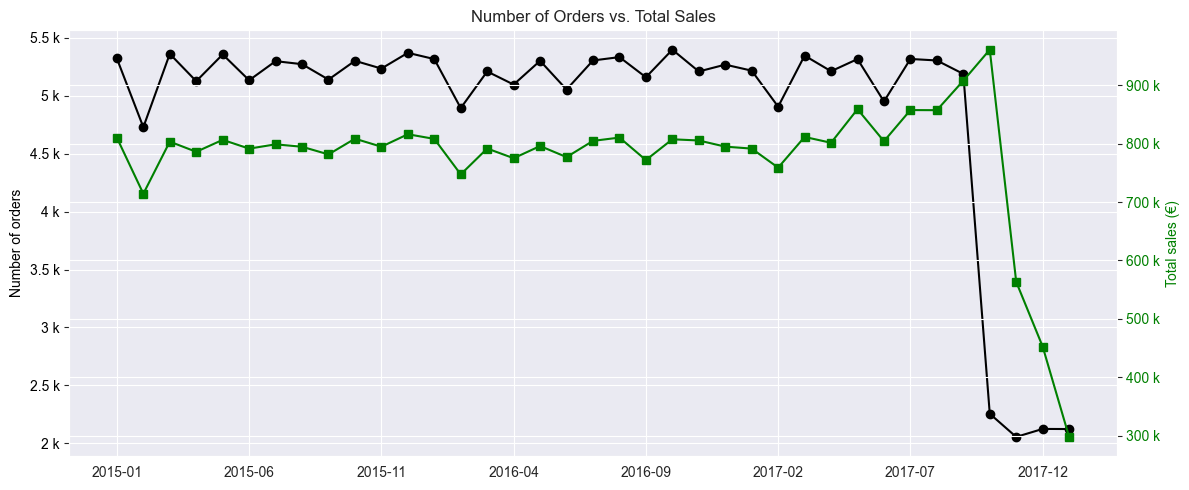

In [20]:
plot_orders_and_sales(df)

**Interpretation:**   
The dataset exhibits stable order volume (5-6k orders per month) and consistent total sales (800-900k) throughout 2015-2017, indicating reliable business operations with steady customer demand.   
A sharp decline is observed at the end of 2017, where both order count and revenue plummet significantly—likely due to incomplete data capture for the final months rather than actual business deterioration.

In [21]:
# Cutting of incomplete data
df = (df[df['order date (DateOrders)'] <= '2017-10']
    .sort_values('order date (DateOrders)')
    .reset_index(drop=True))

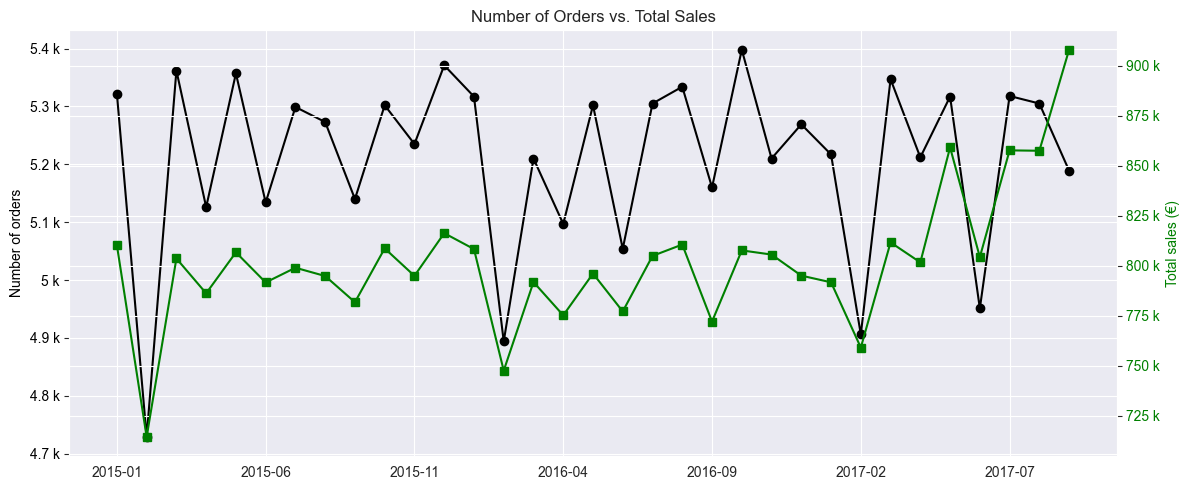

In [22]:
plot_orders_and_sales(df)

---
## Market analysis

Average sales performance varies significantly across different markets.

In [23]:
# Compare average sales by market
market_total = df.groupby('Market')['Order Item Total'].mean().sort_values(ascending=False)
market_total

Market
Europe          157.013110
LATAM           153.645418
Pacific Asia    151.976678
Africa          151.867022
USCA            151.624180
Name: Order Item Total, dtype: float64

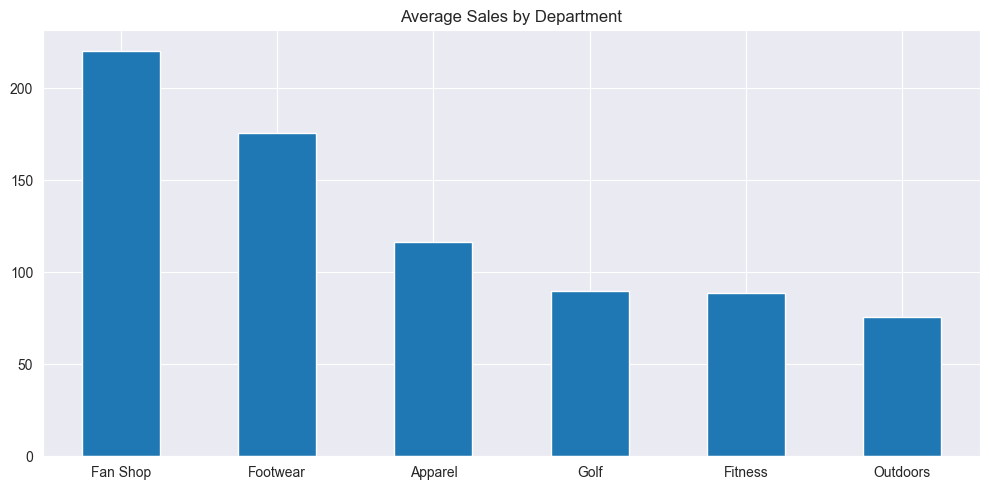

In [24]:
# Compare average sales by department
dept_total = df.groupby('Department Name')['Order Item Total'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
dept_total.plot(kind='bar', ax=ax)
plt.title('Average Sales by Department')
plt.xlabel('')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()

---
## Data type optimazation

Converting columns to more efficient dtypes reduces memory usage and improves performance for subsequent analyses.

In [25]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),order date (DateOrders),Order Item Discount,Order Item Product Price,Order Item Quantity,Order Item Total,Product Category Id
count,171962.000000,171962.000000,171962,1.719620e+05,171962.000000,171962.000000,171962.000000,171962.000000
mean,3.497249,2.931944,2016-05-17 01:52:21.930310400,1.991488e+01,133.594672,2.182383,153.802826,30.099208
min,0.000000,0.000000,2015-01-01 00:00:00,-2.290000e-07,9.990000,1.000000,9.990000,2.000000
25%,2.000000,2.000000,2015-09-08 21:48:15,5.760000e+00,50.000000,1.000000,75.000000,18.000000
50%,3.000000,4.000000,2016-05-17 09:27:00,1.400000e+01,59.990002,1.000000,123.490005,29.000000
75%,5.000000,4.000000,2017-01-23 09:16:00,2.999000e+01,199.990005,3.000000,199.950008,45.000000
max,6.000000,4.000000,2017-09-30 23:59:00,5.000000e+02,1999.989990,5.000000,1699.989990,48.000000
std,1.623859,1.374460,NaN,1.922372e+01,117.608242,1.466420,101.833537,13.716604


In [26]:
df.describe(exclude='number')

,Department Name,Market,order date (DateOrders),Order Status,Shipping Mode
count,171962,171962,171962,171962,171962
unique,6,5,NaN,6,4
top,Fan Shop,LATAM,NaN,COMPLETE,Standard Class
freq,66250,51594,NaN,75293,102655
mean,NaN,NaN,2016-05-17 01:52:21.930310400,NaN,NaN
min,NaN,NaN,2015-01-01 00:00:00,NaN,NaN
25%,NaN,NaN,2015-09-08 21:48:15,NaN,NaN
50%,NaN,NaN,2016-05-17 09:27:00,NaN,NaN
75%,NaN,NaN,2017-01-23 09:16:00,NaN,NaN
max,NaN,NaN,2017-09-30 23:59:00,NaN,NaN


In [27]:
col_dtype = {
    'Days for shipping (real)': 'int8',
    'Days for shipment (scheduled)': 'int8',
    'Department Name': 'category',
    'Market': 'category',
    'Order Item Discount': 'float32',
    'Order Item Product Price': 'float32',
    'Order Item Quantity': 'int8',
    'Order Status': 'category',
    'Product Category Id': 'int8',
    'Shipping Mode': 'category',
    'Order Item Total': 'float32'
}

df = df.astype(col_dtype)

In [28]:
# Verify data types and size after conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171962 entries, 0 to 171961
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Days for shipping (real)       171962 non-null  int8          
 1   Days for shipment (scheduled)  171962 non-null  int8          
 2   Department Name                171962 non-null  category      
 3   Market                         171962 non-null  category      
 4   order date (DateOrders)        171962 non-null  datetime64[ns]
 5   Order Item Discount            171962 non-null  float32       
 6   Order Item Product Price       171962 non-null  float32       
 7   Order Item Quantity            171962 non-null  int8          
 8   Order Item Total               171962 non-null  float32       
 9   Order Status                   171962 non-null  category      
 10  Product Category Id            171962 non-null  int8          
 11  

In [29]:
# Export DataCo dataset
df.to_parquet(export_dir / 'dataco_df.parquet')
print('Processed datasets saved.')

Processed datasets saved.


## Key EDA Takeaways

- The dataset comprises 171,962 orders spanning 34 months (Jan 2015–Oct 2017) across 6 departments and 5 geographic markets, with stable monthly volume (5–6k orders) throughout the analysis period
- Temporal patterns reveal consistent business operations with steady order counts and total sales, but data since October 2017 is incomplete and excluded from further analysis
- Shipping reliability is high: median real shipping time of 3 days closely matches the scheduled 4-day target, with minimal variance across shipping modes
- Data type optimization (int8, float32, category) reduces memory footprint from 16.5 MB to 4.6 MB, enabling efficient processing for feature engineering

The cleaned and reconstructed dataset is now ready for feature engineering and predictive modeling.
